In [1]:
import sys
sys.path.append("/home/atuin/v120bb/v120bb18/UnReflectAnything")

import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms

from PIL import Image
from utilities import panelize, rgb
from main import load_and_process_config,create_model_from_config
from dataset import from_config
# Load autoreload for development
%load_ext autoreload
%autoreload 2    

In [3]:
config = load_and_process_config("config_train.yaml")
dataset = from_config(config)["training"]
model = create_model_from_config(config,device="cuda")

DATASET  [16:14:21] Processing 3 datasets: ['SCRREAM', 'HOUSECAT6D', 'CROMO']

DATASET  [16:14:21] Using all scenes except VAL_SCENES for SCRREAM training

DATASET  [16:14:21]   ✓ Created training dataset for SCRREAM: 14770 samples (excluding 2 val scenes)

DATASET  [16:14:21]   ✓ Created validation dataset for SCRREAM: 1667 samples from 2 scenes

DATASET  [16:14:21] Using all scenes except VAL_SCENES for HOUSECAT6D training

...

DATASET  [16:14:22] === Dataset Creation Summary ===

DATASET  [16:14:22] Training:   38329 total samples

DATASET  [16:14:22] Validation: 33276 total samples

DATASET  [16:14:22] Test:       33276 total samples

MODEL    [16:14:23] Model with class RGBDistillDecomposer created with 370,859,592 parameters

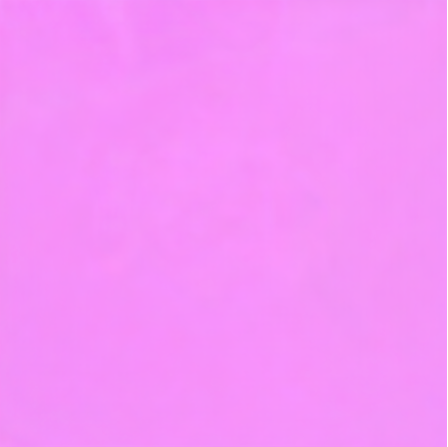

In [4]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)
# light_pos = torch.tensor([0.0, 0.1, -0.1]).cuda()

for b, batch in enumerate(dataloader):
    image = batch["raw"].cuda(non_blocking=True)
    model_input = {"rgb":image}
    out = model(model_input)
    rgb(out["specular"][0],resize=(448,448))
    break

In [7]:
for k,v in out.items():
    print(k,v.shape)

diffuse torch.Size([1, 3, 896, 896])
specular torch.Size([1, 4, 896, 896])
highlight torch.Size([1, 1, 896, 896])
